<a href="https://colab.research.google.com/github/burisvictor40-alt/dataset/blob/main/AnaliseDeDados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns



#COLETA DOS DADOS E INFORMAÇÕES BÁSICAS
df = pd.read_csv('https://raw.githubusercontent.com/burisvictor40-alt/dataset/main/Dados_Violencia_Contra_Mulher.csv', encoding='latin1', sep=';')

print('\n---Estrutura Geral da Base de Dados---\n')
df.info()

print('\n---Descrição dos Dados---\n\n', df.describe())

print('\n---Quantidade de Linhas e Colunas---\n\n', df.shape)

print('\n---Visualização dos Dados---\n', df.head())

#LIMPEZA DOS DADOS

df.columns = [
    'cisp',
    'aisp',
    'risp',
    'municipio',
    'mes_ocorrido',
    'ano_ocorrido',
    'tentativa_feminicidio',
    'total_feminicidio',
    'fase'
]

print('\n---Quantidade de Valores Nulos por Colunas---\n')
print(df.isnull().sum())


print('\n---Quantidade de Linhas Duplicadas---\n')
print(df.duplicated().sum())

print('\n---Quantidade de Municípios onde os dados estão na Fase 3 (Dados que estão na fase final e não sofreram mais alterações.---\n')
df_fechado = df[df['fase'] == 3]
print(df_fechado.shape)



---Estrutura Geral da Base de Dados---

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17165 entries, 0 to 17164
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   CISP                      17165 non-null  int64 
 1   AISP                      17165 non-null  int64 
 2   RISP                      17165 non-null  int64 
 3   Município                 17165 non-null  object
 4   Mês                       17165 non-null  int64 
 5   Ano                       17165 non-null  int64 
 6   Feminicídio               17165 non-null  int64 
 7   Tentativa de feminicídio  17165 non-null  int64 
 8   Fase                      17165 non-null  int64 
dtypes: int64(8), object(1)
memory usage: 1.2+ MB

---Descrição dos Dados---

                CISP          AISP          RISP           Mês           Ano  \
count  17165.000000  17165.000000  17165.000000  17165.000000  17165.000000   
mean      84.583746 

---O gráfico mostra o ponto fora da curva nos 10 municípios onde o índice feminicídio é maior.---



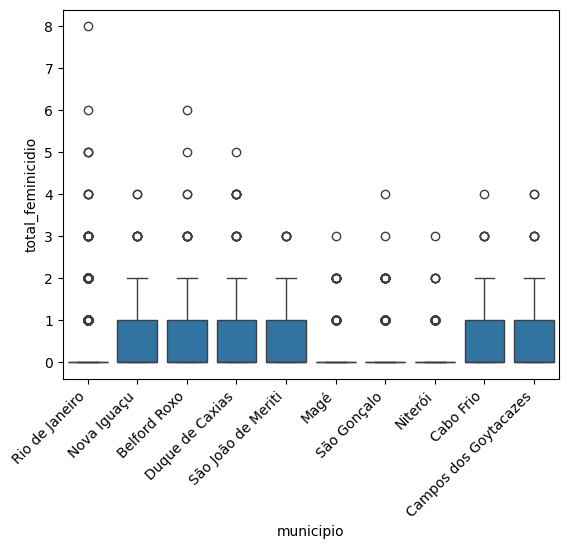

In [2]:
print('---O gráfico mostra o ponto fora da curva nos 10 municípios onde o índice feminicídio é maior.---\n')
municipios_maior_indice = df.groupby('municipio')['total_feminicidio'].sum().nlargest(10).index

df_municipios10 = df[df['municipio'].isin(municipios_maior_indice)]

sns.boxplot(data=df_municipios10, x='municipio', y='total_feminicidio')
plt.xticks(rotation=45, ha='right')
plt.show()

In [3]:
print('---Os prints a seguir mostram a média, desvio padrão e z-score dos dados da coluna(total_feminicidios)---\n')

zscores = (df['total_feminicidio'] - df['total_feminicidio'].mean()) / df['total_feminicidio'].std()

print('Média:', df['total_feminicidio'].mean())
print('Desvio Padrão:', df['total_feminicidio'].std())
print('Z-Score:', zscores)



---Os prints a seguir mostram a média, desvio padrão e z-score dos dados da coluna(total_feminicidios)---

Média: 0.17110399067870666
Desvio Padrão: 0.49798402600129904
Z-Score: 0       -0.343593
1       -0.343593
2       -0.343593
3       -0.343593
4        1.664503
           ...   
17160   -0.343593
17161   -0.343593
17162   -0.343593
17163   -0.343593
17164   -0.343593
Name: total_feminicidio, Length: 17165, dtype: float64


In [4]:
print('---O gráfico vai mostrar a quantidade total de feminicídios em cada município onde o índice e maior.---\n')

municipios_maior_indice = df['municipio'].value_counts().nlargest(10)

df_indice = municipios_maior_indice.reset_index()
df_indice.columns = ['municipio', 'total_feminicidio']

fig = px.line(
    df_indice,
    x='municipio',
    y='total_feminicidio',
    title='Quantidade de Ocorrências por Municípios',
    labels={'municipio': 'Municípios', 'total_feminicidio': 'Quantidade de Ocorrências'},
    markers=True

)

fig.show()

---O gráfico vai mostrar a quantidade total de feminicídios em cada município onde o índice e maior.---

